# Task 4: Confidence-Based Strategy (UCB1)
**Group Number:** G = 225  
**Assignment:** DRL Semester 2 – Phase #1 (MAB)  
**Strategy:** Upper Confidence Bound (UCB1) — give under-explored medicines a statistical bonus that shrinks as evidence accumulates, naturally balancing exploration and exploitation without a fixed ε parameter.

In [1]:
# ─────────────────────────────────────────────────────────────────
# CELL 0 – Library Imports
# ─────────────────────────────────────────────────────────────────

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# ─────────────────────────────────────────────────────────────────
# CELL 1 – Restore Group Configuration & Reproducibility Seeds
#
# Loads the group configuration saved by Task 1 (group_config.json)
# and re-seeds the random engine to the same G=225 value so that
# simulate_treatment() produces reproducible Bernoulli draws.
# ─────────────────────────────────────────────────────────────────

# ── Locate the data directory relative to this notebook ──────────
NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__"))
DATA_DIR     = os.path.join(NOTEBOOK_DIR, "data")
CONFIG_PATH  = os.path.join(DATA_DIR, "group_config.json")
PARQUET_PATH = os.path.join(DATA_DIR, "df_base.parquet")

# ── Load configuration ────────────────────────────────────────────
with open(CONFIG_PATH, "r") as f:
    cfg = json.load(f)

G      = cfg["G"]
K      = cfg["K"]
TRUE_P = cfg["TRUE_P"]

# ── Re-seed for reproducibility (same seed as all other tasks) ────
np.random.seed(G)

print("Configuration restored from group_config.json")
print(f"  G (Group Number)              : {G}")
print(f"  K (Number of Medicines/Arms)  : {K}")
print(f"  TRUE_P (Hidden Probabilities) : {TRUE_P}")

Configuration restored from group_config.json
  G (Group Number)              : 225
  K (Number of Medicines/Arms)  : 5
  TRUE_P (Hidden Probabilities) : [0.61, 0.68, 0.75, 0.4, 0.47]


In [3]:
# ─────────────────────────────────────────────────────────────────
# CELL 2 – Load df_base from Parquet
#
# Reads the clean base DataFrame persisted by Task 1.
# patient_id is restored as the index to match the original schema.
# ─────────────────────────────────────────────────────────────────

df_base = pd.read_parquet(PARQUET_PATH)
df_base.set_index("patient_id", inplace=True)

print(f"df_base loaded: {df_base.shape[0]} rows × {df_base.shape[1]} columns")
print(f"Columns        : {list(df_base.columns)}")
print()
print("First 5 rows (dynamic columns should be NaN):")
print(df_base.head())

df_base loaded: 1000 rows × 4 columns
Columns        : ['severity_score', 'assigned_medicine', 'clinical_outcome', 'utility_score']

First 5 rows (dynamic columns should be NaN):
            severity_score  assigned_medicine  clinical_outcome  utility_score
patient_id                                                                    
0                        1                NaN               NaN            NaN
1                        2                NaN               NaN            NaN
2                        3                NaN               NaN            NaN
3                        4                NaN               NaN            NaN
4                        5                NaN               NaN            NaN


In [4]:
# ─────────────────────────────────────────────────────────────────
# CELL 3 – Environmental Feedback Engine: simulate_treatment()
#
# Identical definition to Tasks 1, 2, and 3. Redefined here so
# this notebook is fully self-contained when run independently.
# ─────────────────────────────────────────────────────────────────

def simulate_treatment(medicine_idx: int, severity_score: int) -> tuple:
    """
    Simulate administering a medicine to a patient.

    Returns
    -------
    (clinical_outcome, utility_score) : tuple(int, float)
      clinical_outcome – 1 if recovered, 0 otherwise (Bernoulli trial)
      utility_score    – severity-penalised reward: outcome × (1 − sev/10)
    """
    success_prob     = TRUE_P[medicine_idx]
    clinical_outcome = int(np.random.binomial(1, success_prob))
    utility_score    = clinical_outcome * (1 - severity_score / 10)
    return (clinical_outcome, utility_score)

print("simulate_treatment() defined.")

simulate_treatment() defined.


In [5]:
# ─────────────────────────────────────────────────────────────────
# CELL 4 – Task 4: Confidence-Based Strategy (UCB1)
#
# Algorithm outline
# -----------------
# UCB1 resolves the exploration–exploitation dilemma without a
# fixed ε by augmenting each arm's empirical mean Q(i) with an
# upper confidence bonus that is large for under-pulled arms and
# shrinks as evidence accumulates:
#
#   UCB Score(i) = Q_t(i) + c × sqrt(2 × ln(t) / N_t(i))
#
# where:
#   Q_t(i)  – empirical success rate = success_counts[i] / pull_counts[i]
#   t       – global time step (1-indexed, ranges 1 → 1000)
#   N_t(i)  – number of pulls for arm i so far
#   c       – exploration constant = 1 (standard UCB1)
#
# Phase 1 – Mandatory Initialisation (patients 0 → K-1):
#   Pull every medicine exactly once (round-robin) to avoid
#   division-by-zero inside the radical.
#   assigned_medicine = t - 1  (t is 1-indexed → arms 0, 1, 2, 3, 4)
#
# Phase 2 – UCB1 Selection (patients K → 999):
#   Select arm i* = argmax UCB Score(i) and simulate treatment.
#
# Statistics updated using clinical_outcome (binary 0/1).
# Cumulative reward tracked using utility_score.
# ─────────────────────────────────────────────────────────────────

# ── Exploration constant ─────────────────────────────────────────
# c = 1 leaves the factor of 2 already inside the radical,
# matching the standard UCB1 specification.
c = 1

# ── Working copy of the base DataFrame ───────────────────────────
df_ucb = df_base.copy(deep=True)

# ── Bandit statistics accumulators ───────────────────────────────
success_counts = np.zeros(K, dtype=float)   # total recoveries per medicine
pull_counts    = np.zeros(K, dtype=float)   # total pulls per medicine

# ── Reward tracking ───────────────────────────────────────────────
cumulative_reward  = 0.0
ucb_utility_history = []   # running cumulative reward at every step

# ── Main simulation loop (t is 1-indexed as per UCB1 formula) ─────
for patient_id in range(1000):

    # t is the 1-indexed global time step used inside the UCB formula
    t = patient_id + 1

    severity = int(df_ucb.at[patient_id, "severity_score"])

    # ── Phase 1: Mandatory Initialisation (patients 0 to K-1) ────
    # Pull every arm exactly once to guarantee pull_counts[i] > 0
    # before entering the UCB score calculation.
    if patient_id < K:
        chosen_medicine = t - 1          # t=1→arm0, t=2→arm1, …, t=K→arm(K-1)

    # ── Phase 2: UCB1 Selection (patients K to 999) ───────────────
    else:
        # Empirical success rate for each arm
        Q = success_counts / pull_counts  # shape (K,); pull_counts > 0 guaranteed

        # Exploration bonus: shrinks as N_t(i) grows, grows as t grows
        bonus = c * np.sqrt(2 * np.log(t) / pull_counts)

        ucb_scores      = Q + bonus
        chosen_medicine = int(np.argmax(ucb_scores))

    # ── Simulate treatment and collect feedback ───────────────────
    clinical_outcome, utility_score = simulate_treatment(chosen_medicine, severity)

    # ── Update bandit statistics (binary clinical_outcome only) ───
    success_counts[chosen_medicine] += clinical_outcome
    pull_counts[chosen_medicine]    += 1

    # ── Populate df_ucb row-by-row ────────────────────────────────
    df_ucb.at[patient_id, "assigned_medicine"] = chosen_medicine
    df_ucb.at[patient_id, "clinical_outcome"]  = clinical_outcome
    df_ucb.at[patient_id, "utility_score"]     = utility_score

    # ── Accumulate reward (utility_score, NOT used for stat update) ─
    cumulative_reward += utility_score
    ucb_utility_history.append(cumulative_reward)

print("UCB1 simulation complete.")
print(f"Total iterations : {len(ucb_utility_history)}")

UCB1 simulation complete.
Total iterations : 1000


In [6]:
# ─────────────────────────────────────────────────────────────────
# CELL 5 – Verification & Output
#
# 1. Final cumulative reward over 1000 patients.
# 2. Pull distribution across all K medicines to confirm that
#    UCB1 converged on the optimal arm (Medicine 2, P=0.75).
# 3. Empirical success rates vs. true hidden probabilities.
# 4. Transition slice df_ucb.iloc[0:10] (initialisation phase).
# ─────────────────────────────────────────────────────────────────

TRUE_OPTIMAL = int(np.argmax(TRUE_P))

# Empirical success rates after full simulation
empirical_rates = success_counts / pull_counts
best_arm_empirical = int(np.argmax(empirical_rates))

print("=" * 60)
print("TASK 4 – UCB1 CONFIDENCE-BASED STRATEGY RESULTS")
print("=" * 60)
print(f"  True optimal medicine : {TRUE_OPTIMAL}  (P = {TRUE_P[TRUE_OPTIMAL]:.2f})")
print()
print(f"  Final cumulative reward (1000 patients) : {cumulative_reward:.4f}")
print()
print("Pull Distribution & Empirical Rates (UCB1 final state):")
print(f"  {'Medicine':<12} {'Pull Count':>12} {'Empirical Rate':>16} {'True P':>10} {'':>12}")
print("  " + "-" * 56)
for idx in range(K):
    marker = "← OPTIMAL" if idx == TRUE_OPTIMAL else ""
    selected = "← SELECTED" if idx == best_arm_empirical and idx != TRUE_OPTIMAL else ""
    tag = marker if marker else selected
    print(f"  Medicine {idx}   {int(pull_counts[idx]):>12}   {empirical_rates[idx]:>14.4f}   "
          f"{TRUE_P[idx]:>8.2f}   {tag}")

print()
print(f"  Best arm by empirical rate : Medicine {best_arm_empirical}  "
      + ("← MATCHES OPTIMAL" if best_arm_empirical == TRUE_OPTIMAL else "← SUBOPTIMAL"))

print()
print("-" * 60)
print("Initialisation phase – df_ucb.iloc[0:10]")
print("(Patients 0–4: forced round-robin | Patients 5–9: UCB1 selection)")
print("-" * 60)
print(df_ucb.reset_index().iloc[0:10].to_string(index=False))
print("=" * 60)

TASK 4 – UCB1 CONFIDENCE-BASED STRATEGY RESULTS
  True optimal medicine : 2  (P = 0.75)

  Final cumulative reward (1000 patients) : 466.7000

Pull Distribution & Empirical Rates (UCB1 final state):
  Medicine       Pull Count   Empirical Rate     True P             
  --------------------------------------------------------
  Medicine 0            164           0.6220       0.61   
  Medicine 1            258           0.6822       0.68   
  Medicine 2            468           0.7415       0.75   ← OPTIMAL
  Medicine 3             60           0.4333       0.40   
  Medicine 4             50           0.3800       0.47   

  Best arm by empirical rate : Medicine 2  ← MATCHES OPTIMAL

------------------------------------------------------------
Initialisation phase – df_ucb.iloc[0:10]
(Patients 0–4: forced round-robin | Patients 5–9: UCB1 selection)
------------------------------------------------------------
 patient_id  severity_score  assigned_medicine  clinical_outcome  utility_sco

In [7]:
# ─────────────────────────────────────────────────────────────────
# CELL 6 – Persist Outputs for Task 5 (Comparative Plots)
#
# Saves df_ucb and ucb_utility_history so the Task 5 notebook can
# load them alongside outputs from Tasks 2 & 3 and generate
# multi-algorithm comparative reward curves without re-running.
# ─────────────────────────────────────────────────────────────────

UCB_PARQUET_PATH = os.path.join(DATA_DIR, "df_ucb.parquet")
UCB_HISTORY_PATH = os.path.join(DATA_DIR, "ucb_utility_history.npy")

# Save df_ucb (reset index so patient_id becomes a regular column)
df_ucb.reset_index().to_parquet(UCB_PARQUET_PATH, index=False)

# Save utility history as a NumPy array
np.save(UCB_HISTORY_PATH, np.array(ucb_utility_history))

print(f"df_ucb saved              → {UCB_PARQUET_PATH}")
print(f"ucb_utility_history saved → {UCB_HISTORY_PATH}")
print(f"df_ucb shape              : {df_ucb.shape}")
print(f"History length            : {len(ucb_utility_history)}")

df_ucb saved              → c:\Users\rohit\OneDrive\Desktop\BITSWILP\2ndSem\DRL\gitcode\SEM2_DRL_ASSIGNMENT_PART1\Phase#1\data\df_ucb.parquet
ucb_utility_history saved → c:\Users\rohit\OneDrive\Desktop\BITSWILP\2ndSem\DRL\gitcode\SEM2_DRL_ASSIGNMENT_PART1\Phase#1\data\ucb_utility_history.npy
df_ucb shape              : (1000, 4)
History length            : 1000


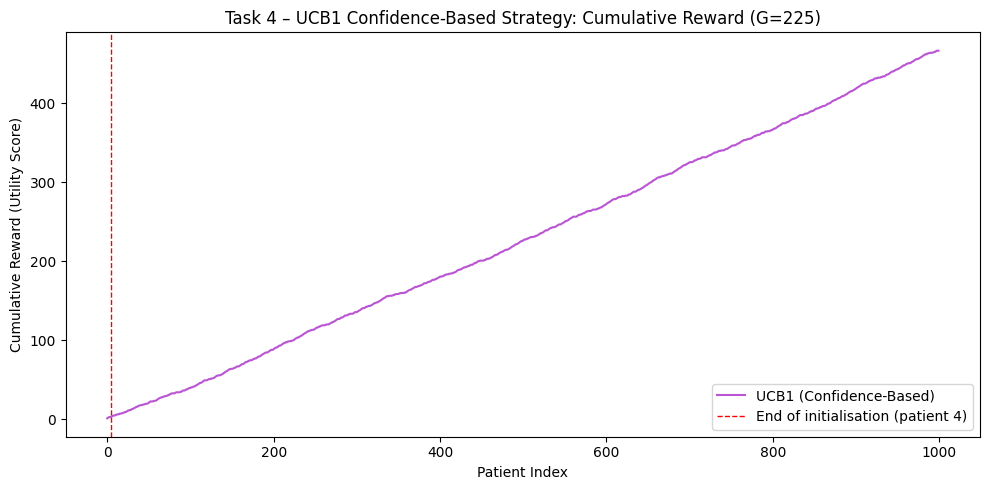

In [8]:
# ─────────────────────────────────────────────────────────────────
# CELL 7 – Quick Reward Curve (Task 4 Preview)
#
# Plots the UCB1 cumulative reward trajectory with annotations
# marking the end of the mandatory initialisation phase.
# The curve should climb steeply once UCB1 identifies Medicine 2
# and allocates most pulls to the optimal arm.
# ─────────────────────────────────────────────────────────────────

plt.figure(figsize=(10, 5))
plt.plot(ucb_utility_history, color="mediumorchid", linewidth=1.5,
         label="UCB1 (Confidence-Based)")
plt.axvline(x=K - 1, color="red", linestyle="--", linewidth=1,
            label=f"End of initialisation (patient {K - 1})")
plt.xlabel("Patient Index")
plt.ylabel("Cumulative Reward (Utility Score)")
plt.title("Task 4 – UCB1 Confidence-Based Strategy: Cumulative Reward (G=225)")
plt.legend()
plt.tight_layout()
plt.show()

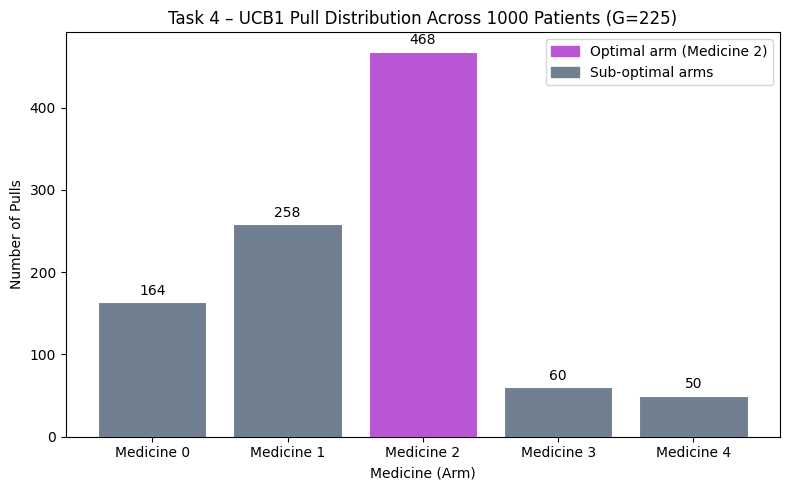

In [9]:
# ─────────────────────────────────────────────────────────────────
# CELL 8 – Pull Distribution Bar Chart
#
# Visualises how many times each medicine was selected across the
# 1000 patients.  An effective UCB1 run should show Medicine 2
# (the optimal arm, P=0.75) dominating the pull count while other
# medicines still receive exploratory pulls.
# ─────────────────────────────────────────────────────────────────

colors = ["mediumorchid" if idx == TRUE_OPTIMAL else "slategray" for idx in range(K)]

plt.figure(figsize=(8, 5))
bars = plt.bar([f"Medicine {i}" for i in range(K)],
               pull_counts.astype(int),
               color=colors, edgecolor="white", linewidth=0.8)

# Annotate each bar with the exact pull count
for bar, count in zip(bars, pull_counts.astype(int)):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 5,
             str(count),
             ha="center", va="bottom", fontsize=10)

plt.xlabel("Medicine (Arm)")
plt.ylabel("Number of Pulls")
plt.title("Task 4 – UCB1 Pull Distribution Across 1000 Patients (G=225)")
plt.legend(
    handles=[
        plt.Rectangle((0, 0), 1, 1, color="mediumorchid", label="Optimal arm (Medicine 2)"),
        plt.Rectangle((0, 0), 1, 1, color="slategray",    label="Sub-optimal arms"),
    ]
)
plt.tight_layout()
plt.show()